# Методы обработки и распознавания изображений 

## Практическое занятие 2: Основы работы с изображениями

In [2]:
#!pip install opencv-python-headless

   ---------------------------------------- 0.0/43.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.8 MB 5.4 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/43.8 MB 13.1 MB/s eta 0:00:04
   --------- ------------------------------ 10.0/43.8 MB 20.2 MB/s eta 0:00:02
   --------------- ------------------------ 16.5/43.8 MB 23.5 MB/s eta 0:00:02
   -------------------- ------------------- 22.0/43.8 MB 24.1 MB/s eta 0:00:01
   ------------------------- -------------- 28.0/43.8 MB 24.6 MB/s eta 0:00:01
   ------------------------------ --------- 33.6/43.8 MB 24.9 MB/s eta 0:00:01
   ----------------------------------- ---- 39.3/43.8 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------  43.8/43.8 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 43.8/43.8 MB 23.0 MB/s eta 0:00:00


In [3]:
# Подготовка окружения

import os
from pathlib import Path
import shutil
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Настройка отображения графиков внутри ноутбука
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [6]:
#Компьютерное представление изображения

# Создадим маленькое синтетическое изображение 4x4 пикселя вручную через NumPy
# Это поможет увидеть "сырой" вид данных
synthetic_array = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0]],
    [[255, 0, 255], [0, 255, 255], [128, 128, 128], [0, 0, 0]],
    [[255, 255, 255], [255, 165, 0], [128, 0, 128], [0, 128, 0]],
    [[255, 192, 203], [173, 216, 230], [255, 255, 0], [0, 255, 127]]
], dtype=np.uint8)

print("Тип данных массива:", synthetic_array.dtype)
print("Размерность (высота, ширина, каналы):", synthetic_array.shape)
print("\nМатрица значений первого красного канала:\n", synthetic_array[:, :, 0])

# Преобразуем массив обратно в объект Image библиотеки Pillow для вывода
img_synthetic = Image.fromarray(synthetic_array)
img_synthetic.show() # Откроется системный просмотрщик

Тип данных массива: uint8
Размерность (высота, ширина, каналы): (4, 4, 3)

Матрица значений первого красного канала:
 [[255   0   0 255]
 [255   0 128   0]
 [255 255 128   0]
 [255 173 255   0]]


Тип (OpenCV): <class 'numpy.ndarray'>
Форма (H, W, C): (4, 4, 3)
dtype: uint8
Минимум / максимум по каналам: 0 255


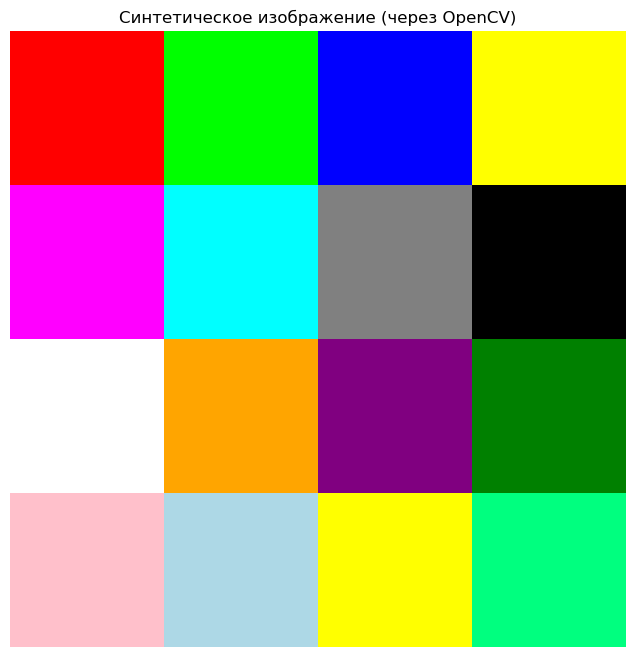

In [11]:
# Представление изображения в OpenCV: BGR-формат и отличие от Pillow

# Преобразуем синтетический массив к формату, который "понимает" OpenCV
synthetic_bgr = cv2.cvtColor(synthetic_array, cv2.COLOR_RGB2BGR)

print("Тип (OpenCV):", type(synthetic_bgr))
print("Форма (H, W, C):", synthetic_bgr.shape)
print("dtype:", synthetic_bgr.dtype)
print("Минимум / максимум по каналам:",
      synthetic_bgr.min(), synthetic_bgr.max())

plt.imshow(cv2.cvtColor(synthetic_bgr, cv2.COLOR_BGR2RGB))
plt.title("Синтетическое изображение (через OpenCV)")
plt.axis("off")
plt.show()

Сравните вывод synthetic_array и synthetic_bgr через print, поясните, почему изображение выглядит одинаково при разных соглашениях о порядке каналов.

Напишите функцию, которая принимает np.ndarray и возвращает информацию: форма, тип, минимум/максимум, среднее по каждому каналу.

## Часть 1. Загрузка одиночного изображения
Для работы будем использовать две основные библиотеки:

* Pillow (PIL Fork) — интуитивная библиотека, идеальна для старта. Работает с объектами Image.
* OpenCV (cv2) — стандарт индустрии компьютерного зрения. По умолчанию загружает цвета в порядке BGR (Blue-Green-Red).

[PIL] Формат: JPEG
[PIL] Режим: RGB
[PIL] Размер: (640, 427)
[PIL] NumPy-форма: (427, 640, 3)
[OpenCV] Форма BGR: (427, 640, 3)
[OpenCV] Минимум / максимум по каналам: 0 255


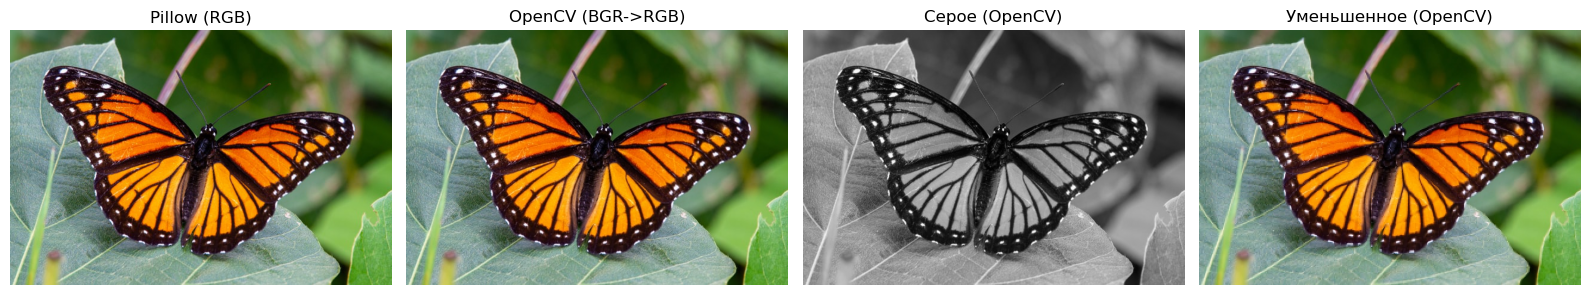

In [14]:
def load_and_inspect_image(filepath: str):
    """
    Загружает изображение через Pillow и OpenCV, сравнивает представления,
    демонстрирует базовые операции OpenCV.
    """
    # --- Pillow ---
    pil_img = Image.open(filepath)
    pil_np = np.array(pil_img)

    print(f"[PIL] Формат: {pil_img.format}")
    print(f"[PIL] Режим: {pil_img.mode}")
    print(f"[PIL] Размер: {pil_img.size}")
    print(f"[PIL] NumPy-форма: {pil_np.shape}")

    # --- OpenCV ---
    cv_img_bgr = cv2.imread(filepath)
    if cv_img_bgr is None:
        print("[OpenCV] Не удалось прочитать изображение.")
        return

    cv_img_rgb = cv2.cvtColor(cv_img_bgr, cv2.COLOR_BGR2RGB)
    print(f"[OpenCV] Форма BGR: {cv_img_bgr.shape}")
    print(f"[OpenCV] Минимум / максимум по каналам:",
          cv_img_bgr.min(), cv_img_bgr.max())

    # --- Простейшие операции ---
    img_gray = cv2.cvtColor(cv_img_bgr, cv2.COLOR_BGR2GRAY)
    img_small = cv2.resize(cv_img_bgr, (0, 0), fx=0.5, fy=0.5,
                           interpolation=cv2.INTER_AREA)

    # Визуальное сравнение
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].set_title('Pillow (RGB)')
    axes[0].imshow(pil_np)
    axes[0].axis('off')

    axes[1].set_title('OpenCV (BGR->RGB)')
    axes[1].imshow(cv_img_rgb)
    axes[1].axis('off')

    axes[2].set_title('Серое (OpenCV)')
    axes[2].imshow(img_gray, cmap='gray')
    axes[2].axis('off')

    axes[3].set_title('Уменьшенное (OpenCV)')
    axes[3].imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

# Пример использования (замените путь на существующий файл)
sample_path = "./butterfly.jpg"
if os.path.exists(sample_path):
    load_and_inspect_image(sample_path)

Добавьте в функцию вывод гистограммы яркостей для img_gray с помощью cv2.calcHist и plt.plot.

## Часть 2. Цветовые пространства
Мы привыкли к RGB, но для алгоритмов часто удобнее другие представления:

* HSV (Hue, Saturation, Value): Оттенок, насыщенность, яркость. Удобно отделять цвет от освещения.
* Градации серого (Grayscale/L): Упрощает данные до одного канала.
* Инверсия цветов: Часто используется как простейший фильтр.

In [27]:
def visualize_color_spaces(image_path: str):
    """
    Загружает изображение через OpenCV и визуализирует различные цветовые пространства
    и простые поточечные преобразования.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Не удалось загрузить изображение:", image_path)
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

    # Инверсия
    inverted = 255 - img_rgb

    r_channel, g_channel, b_channel = cv2.split(img_rgb)

    titles = [
        'Оригинал (RGB)', 'GRAY', 'HSV', 'LAB',
        'YCrCb', 'Инверсия', 'Красный канал', 'Зелёный канал', 'Синий канал'
    ]
    images_to_show = [
        img_rgb, gray, hsv, lab,
        ycrcb, inverted, r_channel, g_channel, b_channel
    ]

    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    axes = axes.ravel()

    for ax, img, title in zip(axes, images_to_show, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

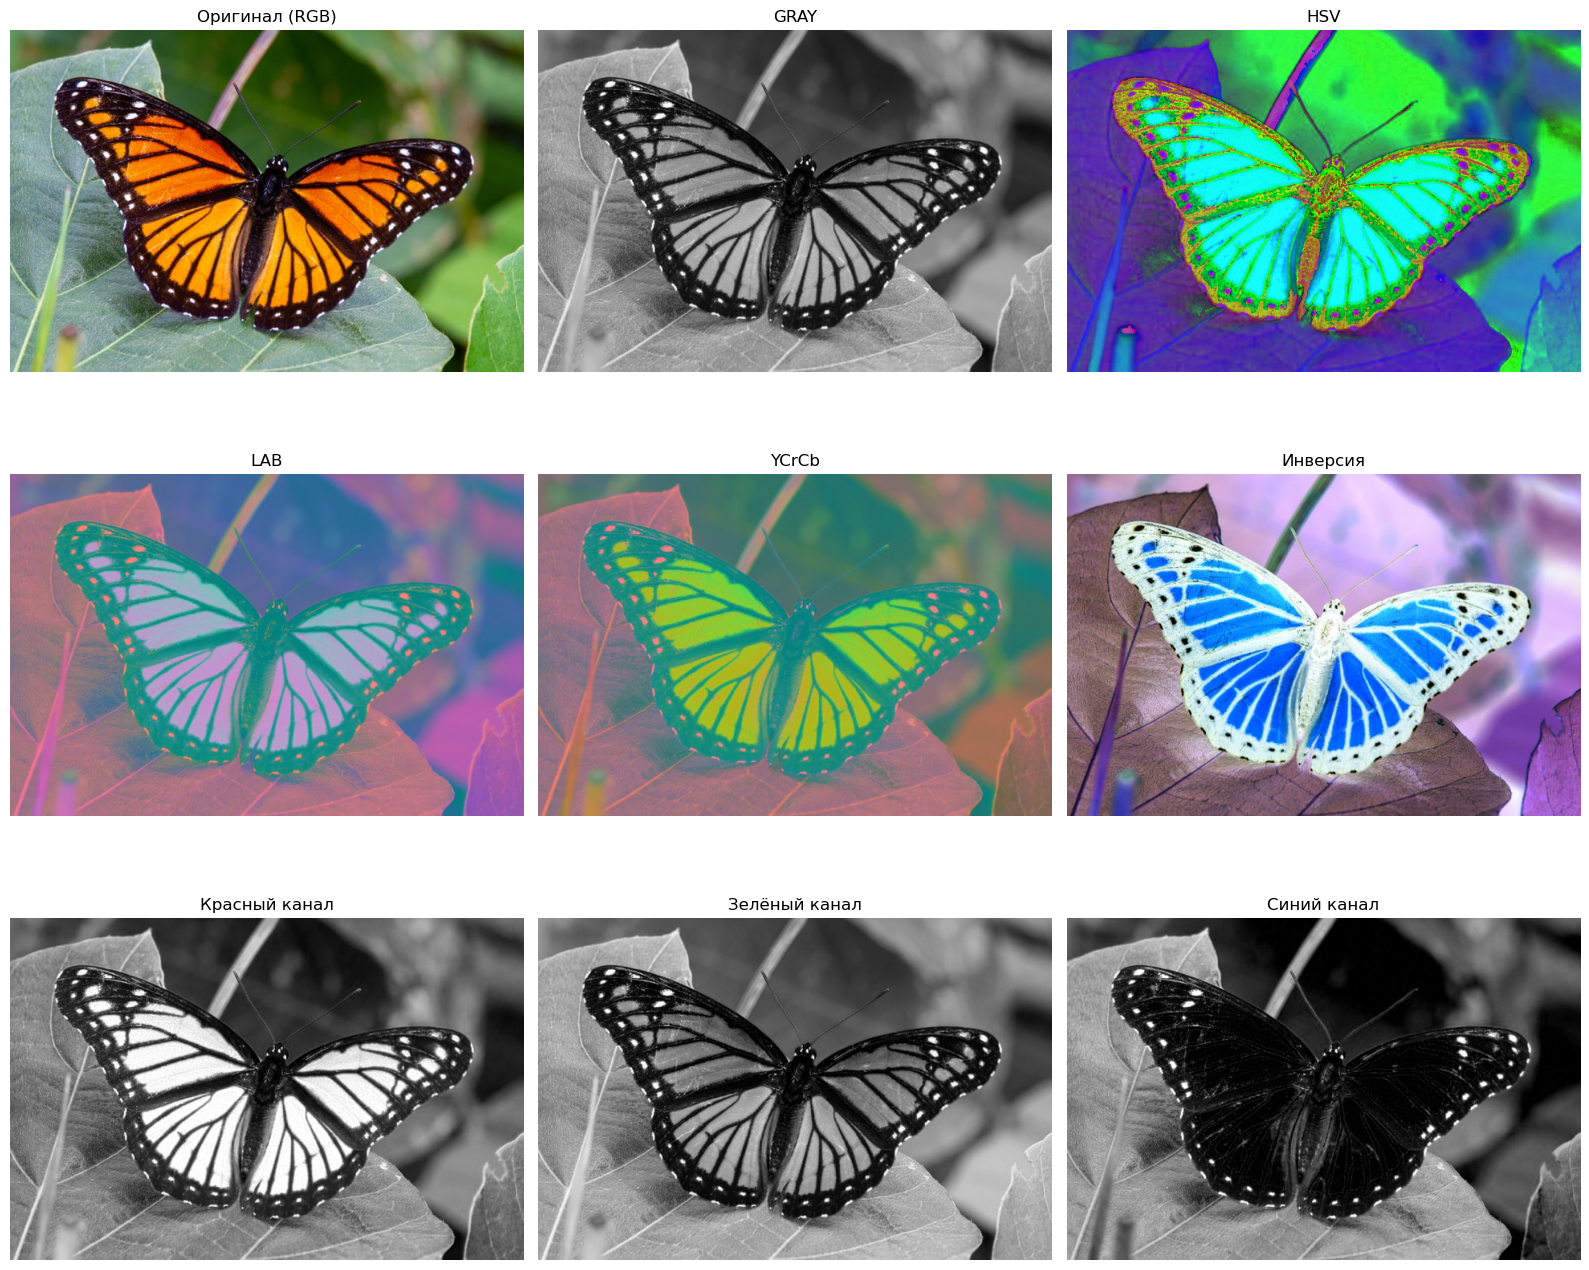

In [28]:
visualize_color_spaces("./butterfly.jpg")

Реализуйте простую цветовую сегментацию в HSV: выделите пиксели с определённым оттенком (например, “красные” области).

Сравните вид изображения в LAB и YCrCb, прокомментируйте различия каналов.

## Часть 3. Пакетная обработка
В реальных задачах изображения почти никогда не обрабатываются по одному файлу: обычно данные лежат в каталогах и подкаталогах, а программа должна автоматически находить изображения, считывать их, преобразовывать и сохранять результат. Поэтому важно освоить полный цикл пакетной обработки: обход папок, загрузку через OpenCV, базовую предобработку, сохранение результата и контроль возможных ошибок чтения.

Среда 'dataset_practical' подготовлена.
Найдено 4 изображений.

cat_1.jpg            | Shape: (100, 150, 3) | Mean Color (R,G,B): [254   0   0]
cat_2.png            | Shape: (100, 150, 3) | Mean Color (R,G,B): [  0 255   0]
dog_1.jpg            | Shape: (100, 150, 3) | Mean Color (R,G,B): [  0   0 254]
dog_2.jpeg           | Shape: (100, 150, 3) | Mean Color (R,G,B): [255 255   0]


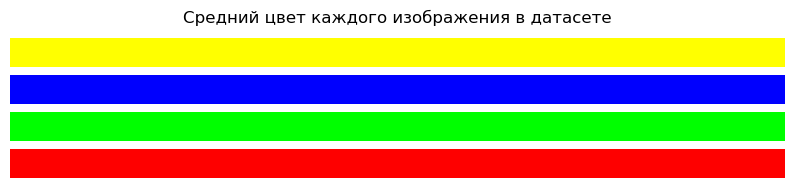

In [10]:
def setup_batch_environment(root_dir: str = "dataset_practical"):
    """
    Создает тестовую структуру папок с несколькими изображениями разных форматов.
    Используется только для демонстрации пакетной загрузки.
    """
    if not os.path.exists(root_dir):
        os.makedirs(os.path.join(root_dir, "cats"))
        os.makedirs(os.path.join(root_dir, "dogs"))
        
        # Создание простых цветных прямоугольников вместо поиска реальных файлов
        colors = {
            "cat_1.jpg": (255, 0, 0),
            "cat_2.png": (0, 255, 0),
            "dog_1.jpg": (0, 0, 255),
            "dog_2.jpeg": (255, 255, 0)
        }
        
        for name, color in colors.items():
            folder = "cats" if name.startswith("cat") else "dogs"
            arr = np.full((100, 150, 3), color, dtype=np.uint8)
            Image.fromarray(arr).save(os.path.join(root_dir, folder, name))
            
    print(f"Среда '{root_dir}' подготовлена.")

setup_batch_environment()

def batch_load_images(directory: str):
    """
    Рекурсивно ищет все изображения в папке и подпапках,
    вычисляет средний цвет каждого изображения и строит галерею.
    """
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    image_paths = []
    
    # Собираем пути ко всем файлам
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))
                
    print(f"Найдено {len(image_paths)} изображений.\n")
    
    avg_colors = []
    
    # Обрабатываем каждое изображение
    for path in image_paths:
        try:
            with Image.open(path) as img:
                # Приводим все к единому размеру для наглядности галереи
                img_resized = img.resize((150, 100))
                img_np = np.array(img_resized)
                
                # Вычисляем средний цвет (усреднение по осям высоты и ширины)
                mean_color = np.mean(img_np, axis=(0, 1)).astype(int)
                avg_colors.append(mean_color)
                
                print(f"{os.path.basename(path):<20} | Shape: {img_np.shape} | Mean Color (R,G,B): {mean_color}")
        except Exception as e:
            print(f"Ошибка при чтении {path}: {e}")
            
    # Визуализация результатов пакетной обработки
    if avg_colors:
        fig, ax = plt.subplots(figsize=(10, 2))
        ax.barh(range(len(avg_colors)), [1]*len(avg_colors), left=0, height=0.8, 
                color=[c/255 for c in avg_colors]) # Нормализация для Matplotlib
        ax.set_yticks(range(len(avg_colors)))
        ax.set_yticklabels([os.path.basename(p) for p in image_paths])
        ax.set_xlim(0, 1)
        ax.set_title("Средний цвет каждого изображения в датасете")
        ax.axis('off')
        plt.show()

batch_load_images("dataset_practical")

Разберем логику функции batch_load_images из предыдущего примера.

Шаг 1. Рекурсивный поиск файлов (os.walk)

In [ ]:
for root, dirs, files in os.walk(directory):
    for file in files:
        if file.lower().endswith(valid_exts):
            image_paths.append(os.path.join(root, file))

* os.walk() — это команда-путешественник. Она заходит в указанную папку, смотрит, какие там есть файлы и подпапки. Затем она спускается в каждую подпапку и делает то же самое.
* Переменная root хранит путь к текущей папке (например, dataset/cats), files — список имен файлов внутри неё.
* Условие if file.lower().endswith(...) отсеивает мусор: текстовые документы, скрытые системные файлы. Мы берем только .jpg, .png и так далее.
* os.path.join(root, file) собирает полный путь (например, dataset/cats/sleeping_cat.jpg) и складывает его в список image_paths. В итоге у нас получается один большой список со всеми адресами всех фотографий во всех вложенных папках.

Шаг 2. Обработка в цикле

In [ ]:
for path in image_paths:
    with Image.open(path) as img:
        # ... действия с картинкой ...

Теперь, когда у нас есть список путей, мы просто перебираем их. Конструкция with Image.open() as img: — это безопасный способ работы. Python гарантированно закроет файл после выполнения действий, даже если внутри произойдет ошибка. Это критически важно при обработке сотен файлов, иначе память компьютера быстро переполнится незакрытыми дескрипторами.

Шаг 3. Агрегация данных (вычисление среднего цвета)

In [ ]:
img_np = np.array(img_resized)
mean_color = np.mean(img_np, axis=(0, 1)).astype(int)

Здесь происходит магия NumPy. Изображение превращается в трехмерный массив чисел. Команда np.mean(..., axis=(0, 1)) говорит компьютеру: «Сложи все числа по высоте (ось 0) и ширине (ось 1), но оставь каналы (ось 2)». 
На выходе получаем три средних значения: [средний_красный, средний_зеленый, средний_синий]. Это простейший пример извлечения признака (feature extraction) из изображения.

Шаг 4. Визуализация результатов всей пачки.

График в конце этой ячейки — это главная цель пакетной обработки. Он показывает сводную информацию сразу по всем загруженным файлам. Видно горизонтальную полоску для каждого файла, окрашенную в его средний цвет. Это позволяет мгновенно заметить аномалии: например, если одно изображение оказалось черно-белым (полоска будет серой) или сильно пересвеченным (желтой).

## Добавим OpenCV‑версию с нормализацией, изменением размера и сохранением.

### Подготовка тестовой среды
Чтобы пример гарантированно работал в ноутбуке, сначала создадим небольшой искусственный набор изображений средствами OpenCV. Такой подход удобен для практики, потому что он не зависит от наличия внешних файлов на компьютере

In [35]:
# Пакетная обработка изображений

def setup_batch_environment_opencv(root_dir: str = "dataset_practical_cv"):
    """
    Создает демонстрационную структуру папок с тестовыми изображениями средствами OpenCV.
    """
    os.makedirs(root_dir, exist_ok=True)

    class_dirs = ["cats", "dogs"]
    for class_name in class_dirs:
        os.makedirs(os.path.join(root_dir, class_name), exist_ok=True)

    samples = {
        "cats/cat_1.jpg": (255, 0, 0),
        "cats/cat_2.png": (0, 255, 0),
        "dogs/dog_1.jpg": (0, 0, 255),
        "dogs/dog_2.png": (255, 255, 0),
    }

    for rel_path, rgb_color in samples.items():
        full_path = os.path.join(root_dir, rel_path)

        # Формируем простое синтетическое изображение
        img = np.full((180, 240, 3), rgb_color, dtype=np.uint8)

        # Добавляем простые графические элементы
        cv2.rectangle(img, (30, 30), (120, 120), (255, 255, 255), -1)
        cv2.circle(img, (170, 90), 35, (0, 0, 0), -1)
        cv2.putText(
            img,
            Path(rel_path).stem,
            (10, 165),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (128, 128, 128),
            2
        )

        # OpenCV сохраняет в BGR, поэтому перед записью конвертируем
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        ok = cv2.imwrite(full_path, img_bgr)

        if not ok:
            print("Не удалось сохранить:", full_path)

    print(f"Тестовая среда '{root_dir}' подготовлена.")

In [36]:
setup_batch_environment_opencv("dataset_practical_cv")

Тестовая среда 'dataset_practical_cv' подготовлена.


### Пакетная обработка
Теперь реализуем основную функцию пакетной обработки. Она будет рекурсивно искать изображения в папке, изменять размер, при необходимости переводить их в оттенки серого, нормализовать значения пикселей и сохранять обработанные копии в отдельную директорию; такой сценарий типичен для подготовки данных к дальнейшему анализу или обучению моделей.

In [37]:
def batch_process_opencv(
    input_dir: str,
    output_dir: str = "dataset_practical_cv_processed",
    target_size=(128, 128),
    convert_to_gray=True,
    normalize=True
):
    """
    Пакетная обработка изображений:
    - рекурсивный поиск файлов;
    - загрузка через OpenCV;
    - изменение размера;
    - перевод в GRAY;
    - нормализация;
    - сохранение результатов.
    """
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    image_paths = []

    if not os.path.exists(input_dir):
        print(f"Папка '{input_dir}' не существует.")
        return

    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))

    if not image_paths:
        print(f"В папке '{input_dir}' изображения не найдены.")
        return

    print(f"Найдено {len(image_paths)} изображений:")
    for p in image_paths:
        print(" -", p)

    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for path in image_paths:
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            print("Ошибка чтения:", path)
            continue

        # Изменение размера
        img_resized = cv2.resize(
            img_bgr,
            target_size,
            interpolation=cv2.INTER_AREA
        )

        # Преобразование в оттенки серого
        if convert_to_gray:
            processed = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        else:
            processed = img_resized

        # Нормализация в диапазон [0, 1]
        if normalize:
            processed_float = processed.astype(np.float32) / 255.0
            processed_to_save = (processed_float * 255).astype(np.uint8)
        else:
            processed_to_save = processed

        # Сохраняем в подпапку с именем класса
        class_name = Path(path).parent.name
        out_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(out_class_dir, exist_ok=True)

        out_name = Path(path).stem + ("_gray.png" if convert_to_gray else "_proc.png")
        out_path = os.path.join(out_class_dir, out_name)

        ok = cv2.imwrite(out_path, processed_to_save)
        if ok:
            saved_files.append(out_path)
            print(f"[OK] {path} -> {out_path} | shape={processed_to_save.shape}")
        else:
            print(f"[Ошибка записи] {out_path}")

    print(f"\nСохранено файлов: {len(saved_files)}")

    return saved_files

In [38]:
saved_files = batch_process_opencv(
    input_dir="dataset_practical_cv",
    output_dir="dataset_practical_cv_processed",
    target_size=(128, 128),
    convert_to_gray=True,
    normalize=True
)

Найдено 4 изображений:
 - dataset_practical_cv\cats\cat_1.jpg
 - dataset_practical_cv\cats\cat_2.png
 - dataset_practical_cv\dogs\dog_1.jpg
 - dataset_practical_cv\dogs\dog_2.png
[OK] dataset_practical_cv\cats\cat_1.jpg -> dataset_practical_cv_processed\cats\cat_1_gray.png | shape=(128, 128)
[OK] dataset_practical_cv\cats\cat_2.png -> dataset_practical_cv_processed\cats\cat_2_gray.png | shape=(128, 128)
[OK] dataset_practical_cv\dogs\dog_1.jpg -> dataset_practical_cv_processed\dogs\dog_1_gray.png | shape=(128, 128)
[OK] dataset_practical_cv\dogs\dog_2.png -> dataset_practical_cv_processed\dogs\dog_2_gray.png | shape=(128, 128)

Сохранено файлов: 4


### Визуализация результатов
После пакетной обработки можно посмотреть несколько сохраненных изображений. Это позволяет убедиться, что файлы действительно найдены, обработка выполнилась корректно, а результаты были записаны в нужную директорию.

In [39]:
def show_processed_gallery(file_list, max_images=4):
    """
    Отображает несколько обработанных изображений из списка.
    """
    if not file_list:
        print("Список файлов пуст.")
        return

    n = min(max_images, len(file_list))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, file_path in zip(axes, file_list[:n]):
        img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            ax.set_title("Ошибка чтения")
            ax.axis("off")
            continue

        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        ax.set_title(Path(file_path).name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

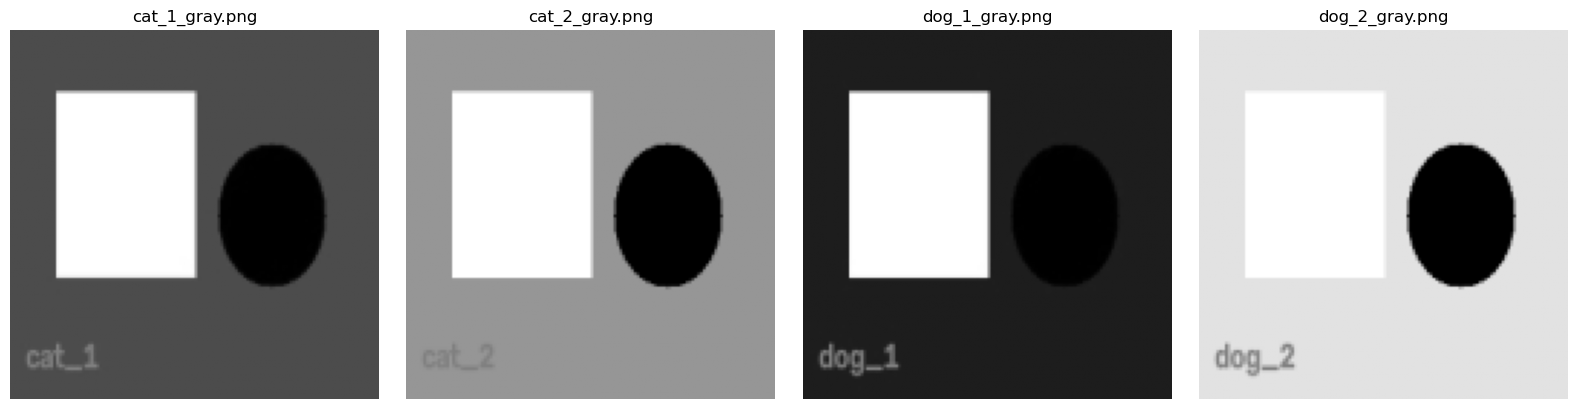

In [40]:
show_processed_gallery(saved_files, max_images=4)

### Вариант 1. Сохранение цветных уменьшенных копий
Иногда требуется не перевод в серый цвет, а только изменение размера и сохранение уменьшенной цветной версии изображения. Такой сценарий часто используется при подготовке миниатюр, предварительном просмотре данных или формировании упрощённых копий набора изображений.

Найдено 4 изображений:
 - dataset_practical_cv\cats\cat_1.jpg
 - dataset_practical_cv\cats\cat_2.png
 - dataset_practical_cv\dogs\dog_1.jpg
 - dataset_practical_cv\dogs\dog_2.png
[OK] dataset_practical_cv\cats\cat_1.jpg -> dataset_practical_cv_color\cats\cat_1_proc.png | shape=(96, 96, 3)
[OK] dataset_practical_cv\cats\cat_2.png -> dataset_practical_cv_color\cats\cat_2_proc.png | shape=(96, 96, 3)
[OK] dataset_practical_cv\dogs\dog_1.jpg -> dataset_practical_cv_color\dogs\dog_1_proc.png | shape=(96, 96, 3)
[OK] dataset_practical_cv\dogs\dog_2.png -> dataset_practical_cv_color\dogs\dog_2_proc.png | shape=(96, 96, 3)

Сохранено файлов: 4


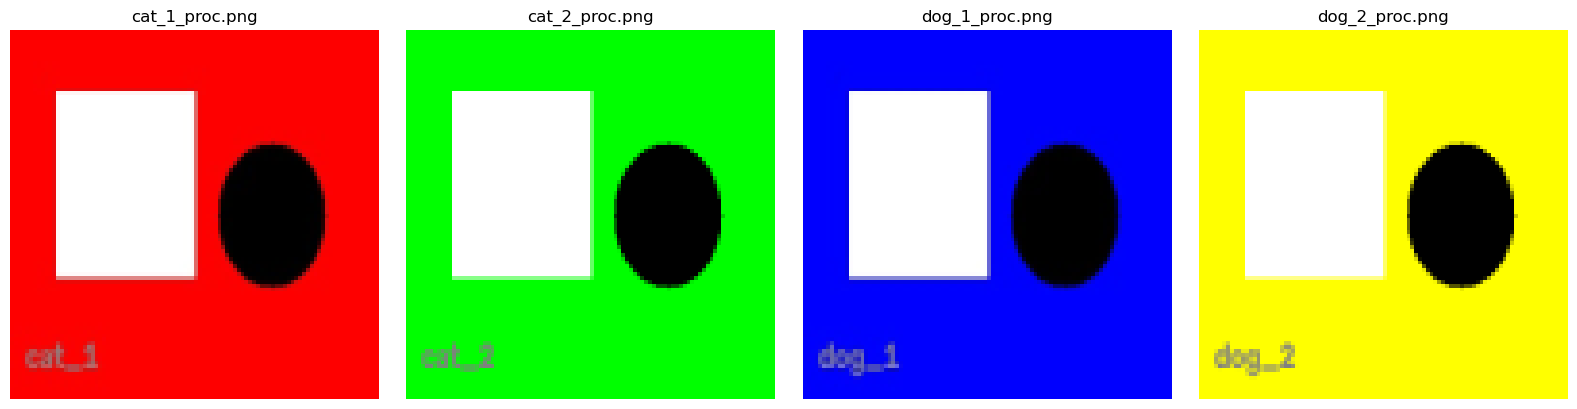

In [41]:
saved_color_files = batch_process_opencv(
    input_dir="dataset_practical_cv",
    output_dir="dataset_practical_cv_color",
    target_size=(96, 96),
    convert_to_gray=False,
    normalize=False
)

show_processed_gallery(saved_color_files, max_images=4)

### Вариант 2. Пакетная обработка со сглаживанием
Перед сохранением изображений можно выполнять сглаживание, например гауссовым фильтром. В OpenCV для этого используется функция cv2.GaussianBlur, которая широко применяется для подавления шума перед последующей сегментацией, выделением контуров или бинаризацией.

In [42]:
def batch_process_with_blur(
    input_dir: str,
    output_dir: str = "dataset_practical_cv_blur",
    target_size=(128, 128),
    blur_ksize=(5, 5)
):
    """
    Пакетная обработка с гауссовым сглаживанием.
    """
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    image_paths = []

    if not os.path.exists(input_dir):
        print(f"Папка '{input_dir}' не существует.")
        return []

    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(valid_exts):
                image_paths.append(os.path.join(root, file))

    if not image_paths:
        print(f"В папке '{input_dir}' изображения не найдены.")
        return []

    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for path in image_paths:
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            print("Ошибка чтения:", path)
            continue

        img_resized = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
        img_blur = cv2.GaussianBlur(img_resized, blur_ksize, 0)

        class_name = Path(path).parent.name
        out_class_dir = os.path.join(output_dir, class_name)
        os.makedirs(out_class_dir, exist_ok=True)

        out_name = Path(path).stem + "_blur.png"
        out_path = os.path.join(out_class_dir, out_name)

        ok = cv2.imwrite(out_path, img_blur)
        if ok:
            saved_files.append(out_path)
            print(f"[OK] {path} -> {out_path}")
        else:
            print(f"[Ошибка записи] {out_path}")

    return saved_files

[OK] dataset_practical_cv\cats\cat_1.jpg -> dataset_practical_cv_blur\cats\cat_1_blur.png
[OK] dataset_practical_cv\cats\cat_2.png -> dataset_practical_cv_blur\cats\cat_2_blur.png
[OK] dataset_practical_cv\dogs\dog_1.jpg -> dataset_practical_cv_blur\dogs\dog_1_blur.png
[OK] dataset_practical_cv\dogs\dog_2.png -> dataset_practical_cv_blur\dogs\dog_2_blur.png


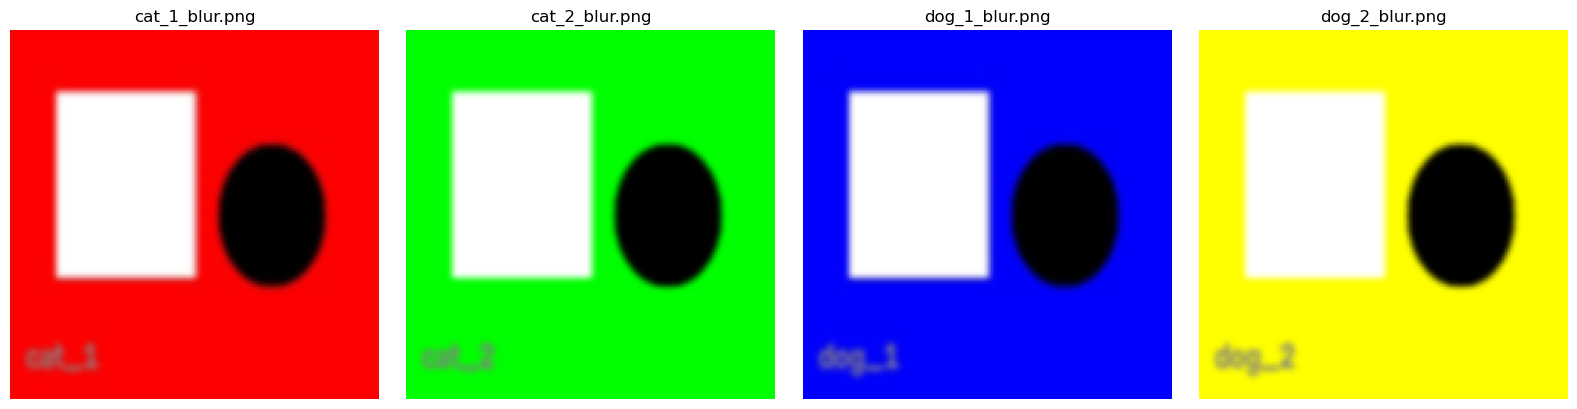

In [43]:
saved_blur_files = batch_process_with_blur(
    input_dir="dataset_practical_cv",
    output_dir="dataset_practical_cv_blur",
    target_size=(128, 128),
    blur_ksize=(5, 5)
)

show_processed_gallery(saved_blur_files, max_images=4)

Выводы:
* os.walk() рекурсивно обходит папку и все вложенные каталоги, что удобно для пакетной обработки наборов изображений.
* cv2.imread() возвращает массив NumPy, но при ошибке чтения возвращает None, поэтому проверка после чтения обязательна.
* cv2.imwrite() сохраняет изображение на диск, но не создаёт отсутствующие директории автоматически, поэтому папки назначения нужно создавать заранее.
* Изменение размера, перевод в серый цвет и сглаживание — это типичные шаги предобработки перед дальнейшим анализом изображения.

Задание 1
Модифицируйте функцию batch_process_opencv так, чтобы она сохраняла одновременно две версии каждого изображения:
* уменьшенную цветную копию;
* уменьшенную версию в оттенках серого.

Задание 2
* Добавьте в функцию параметр use_blur, который при значении True применяет cv2.GaussianBlur перед сохранением.
* Затем сравните визуально результаты обработки для use_blur=False и use_blur=True на нескольких изображениях.

Задание 3
* Напишите собственную функцию подсчёта среднего цвета изображения после изменения размера.
* Результат выведите в консоль в формате: имя файла, размер массива, среднее значение по каналам B, G, R.

Задание 4
* Организуйте пакетную обработку не только по одной папке, но и по нескольким категориям изображений.
* Сохраните структуру подкаталогов в выходной директории и проверьте, что итоговые файлы разложены по тем же классам, что и исходные изображения.

## Часть 4. Бинарные изображения и пороговая обработка
Бинарное изображение — это изображение, в котором каждый пиксель принимает одно из двух значений: обычно 0 для фона и 255 для объекта. Пороговая обработка преобразует полутоновое изображение в бинарное и является одной из базовых операций сегментации в OpenCV; для этого используются функции `cv2.threshold` и `cv2.adaptiveThreshold`.

### 4.1. Подготовка тестового изображения
Чтобы пример был полностью автономным, создадим синтетическое изображение с объектами, неоднородным фоном и шумом. Такой пример особенно полезен, потому что позволяет увидеть различия между глобальным, автоматическим и адаптивным порогом.

In [45]:
# Часть 4. Бинарные изображения и пороговая обработка

def create_threshold_demo_image():
    """
    Создает синтетическое полутоновое изображение
    с неоднородным фоном, объектами и небольшим шумом.
    """
    h, w = 240, 360

    # Градиентный фон
    x = np.linspace(60, 180, w, dtype=np.uint8)
    background = np.tile(x, (h, 1))

    img = background.copy()

    # Добавляем светлые объекты
    cv2.rectangle(img, (30, 40), (130, 180), 230, -1)
    cv2.circle(img, (240, 120), 45, 250, -1)
    cv2.putText(img, "CV", (140, 220),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 220, 3)

    # Добавляем шум
    noise = np.random.normal(0, 12, (h, w)).astype(np.int16)
    noisy = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return noisy

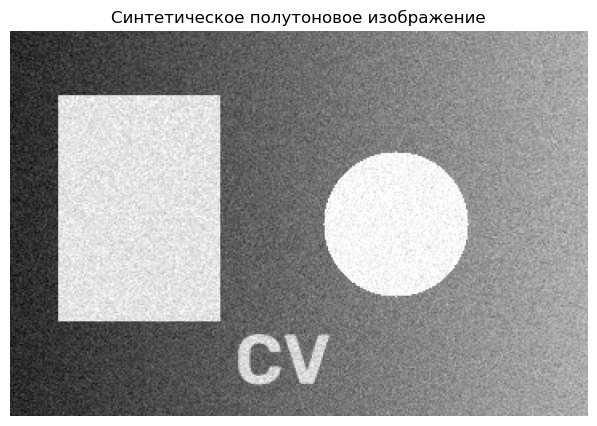

In [46]:
img_demo = create_threshold_demo_image()

plt.figure(figsize=(8, 5))
plt.imshow(img_demo, cmap='gray')
plt.title("Синтетическое полутоновое изображение")
plt.axis("off")
plt.show()

### 4.2. Глобальная пороговая обработка
При глобальной пороговой обработке используется одно общее пороговое значение для всех пикселей изображения. В OpenCV это делается функцией `cv2.threshold`, которая сравнивает значение яркости каждого пикселя с выбранным порогом.

In [47]:
def demo_simple_threshold(gray_img, thresh_value=127):
    """
    Демонстрация простой глобальной пороговой обработки.
    """
    ret, binary = cv2.threshold(gray_img, thresh_value, 255, cv2.THRESH_BINARY)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title(f"Глобальный порог: {ret}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return binary

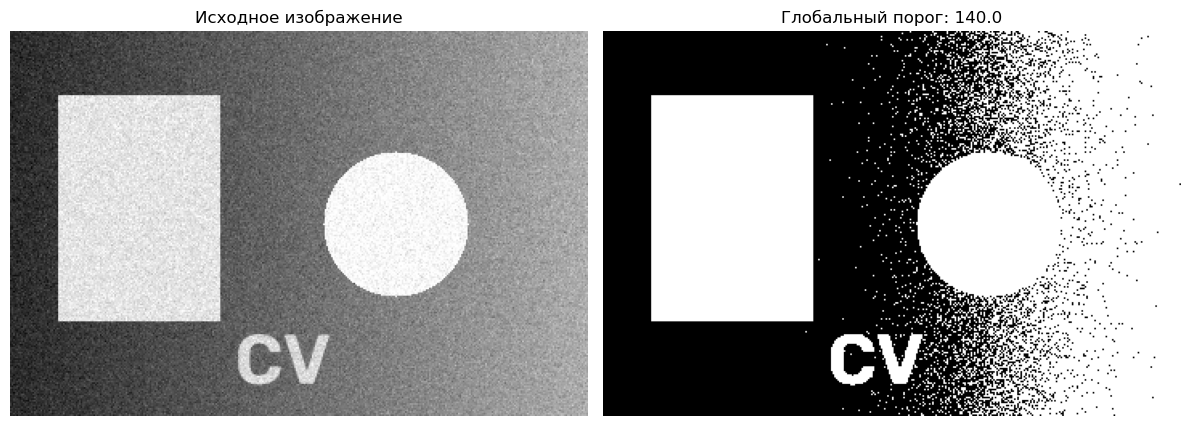

In [48]:
binary_simple = demo_simple_threshold(img_demo, thresh_value=140)

### 4.3. Порог Оцу
Метод Оцу автоматически подбирает порог по гистограмме изображения и особенно хорошо работает, когда распределение яркостей близко к двум классам — фон и объект. В OpenCV он вызывается через `cv2.threshold` с флагом `cv2.THRESH_OTSU`, причём значение порога в аргументе передаётся как 0, а найденный порог возвращается функцией отдельно.

In [49]:
def demo_otsu_threshold(gray_img):
    """
    Демонстрация автоматического порога Оцу.
    """
    ret, binary_otsu = cv2.threshold(
        gray_img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(binary_otsu, cmap='gray')
    axes[1].set_title(f"Порог Оцу: {ret:.2f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    return binary_otsu, ret

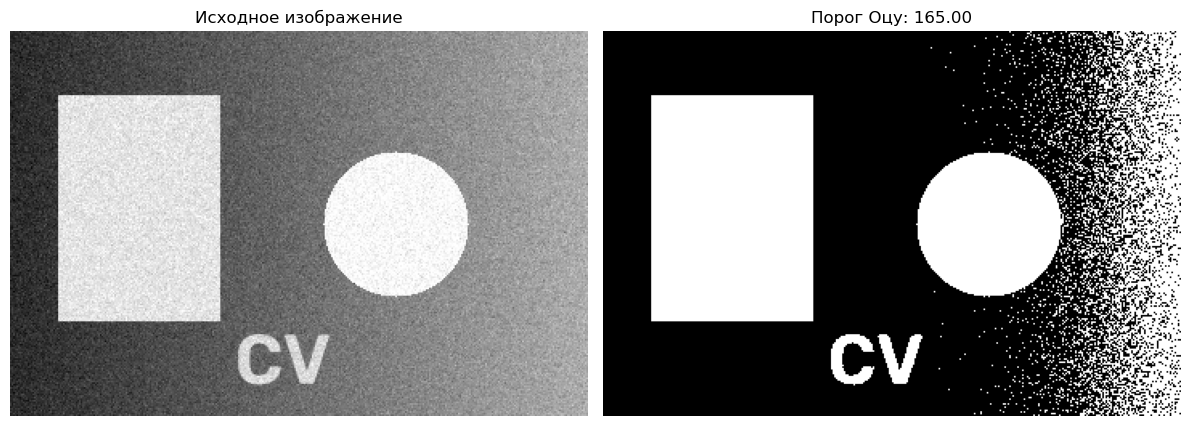

Найденный порог Оцу: 165.0


In [50]:
binary_otsu, otsu_value = demo_otsu_threshold(img_demo)
print("Найденный порог Оцу:", otsu_value)

### 4.4. Адаптивная пороговая обработка
Если освещённость по изображению меняется, то один общий порог может работать плохо. В таких случаях адаптивная пороговая обработка вычисляет порог отдельно для локальных областей изображения, и именно поэтому она часто лучше подходит для неоднородного фона.

In [51]:
def demo_adaptive_threshold(gray_img):
    """
    Демонстрация адаптивной пороговой обработки:
    - по среднему значению;
    - по гауссово-взвешенному среднему.
    """
    binary_mean = cv2.adaptiveThreshold(
        gray_img,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        31,
        5
    )

    binary_gauss = cv2.adaptiveThreshold(
        gray_img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        5
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title("Исходное изображение")
    axes[0].axis("off")

    axes[1].imshow(binary_mean, cmap='gray')
    axes[1].set_title("Adaptive Mean")
    axes[1].axis("off")

    axes[2].imshow(binary_gauss, cmap='gray')
    axes[2].set_title("Adaptive Gaussian")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return binary_mean, binary_gauss

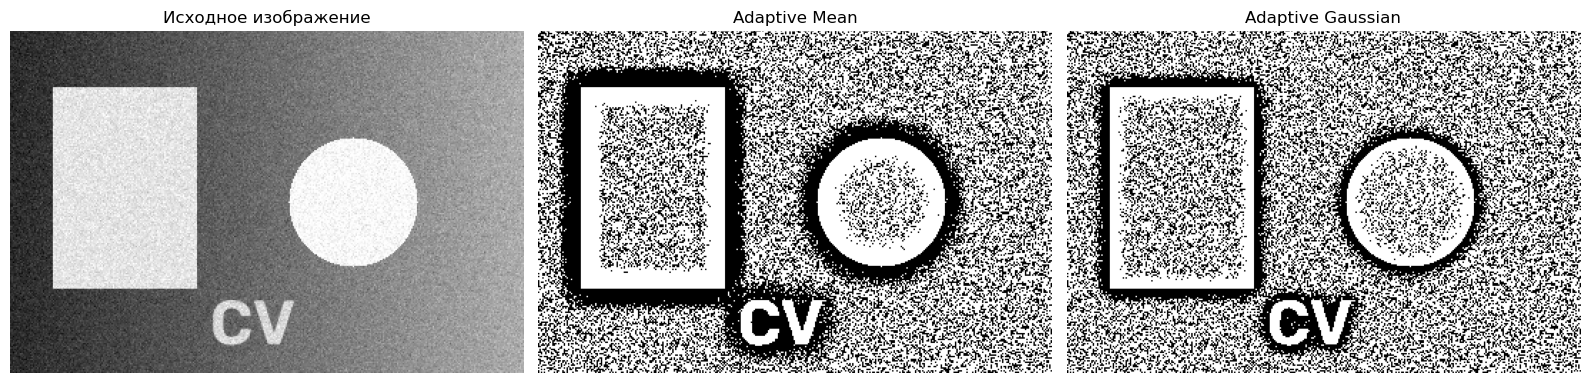

In [52]:
binary_mean, binary_gauss = demo_adaptive_threshold(img_demo)

### 4.5. Сравнение методов бинаризации
Соберем все результаты в одном окне чтобы наглядно сопоставить влияние фиксированного порога, метода Оцу и адаптивной бинаризации на одном и том же изображении.

In [53]:
def compare_threshold_methods(gray_img):
    """
    Сравнение нескольких методов пороговой обработки.
    """
    _, binary_simple = cv2.threshold(gray_img, 140, 255, cv2.THRESH_BINARY)
    _, binary_otsu = cv2.threshold(
        gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    binary_mean = cv2.adaptiveThreshold(
        gray_img, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        31, 5
    )
    binary_gauss = cv2.adaptiveThreshold(
        gray_img, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 5
    )

    titles = [
        "Исходное",
        "Глобальный порог",
        "Otsu",
        "Adaptive Mean",
        "Adaptive Gaussian"
    ]
    images = [
        gray_img,
        binary_simple,
        binary_otsu,
        binary_mean,
        binary_gauss
    ]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

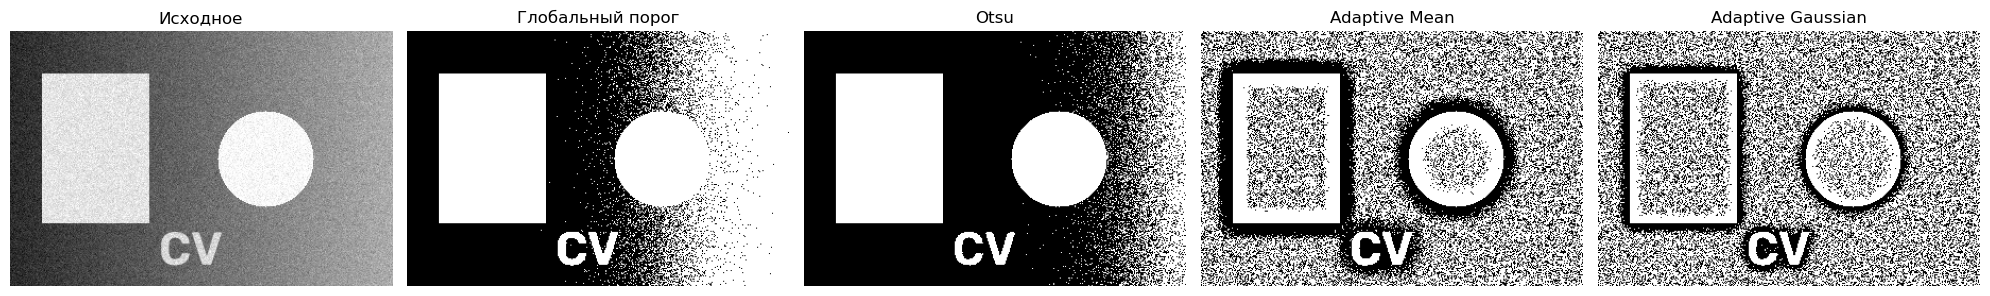

In [54]:
compare_threshold_methods(img_demo)

При простой пороговой обработке используется одно число для всего изображения, и этого часто достаточно только при более‑менее равномерном освещении. Метод Оцу автоматически ищет порог по гистограмме и хорошо подходит для изображений с выраженным разделением на фон и объект, тогда как адаптивная бинаризация лучше работает при локальных изменениях яркости.

Задание 1
* Измените значение глобального порога в функции demo_simple_threshold и сравните визуально результаты для 80, 120, 160 и 200.
* Определите, при каком значении объекты выделяются лучше всего.

Задание 2
* Сравните метод Оцу и два варианта адаптивной бинаризации на изображении с неравномерным фоном.
* Кратко объясните, почему результаты отличаются.

Задание 3
* Добавьте перед бинаризацией сглаживание cv2.GaussianBlur(gray_img, (5, 5), 0) и оцените, как оно влияет на шум и качество выделения объектов; предварительное сглаживание часто улучшает работу порога Оцу на шумных изображениях.

Задание 4
* Загрузите реальное изображение с текстом или объектами на неоднородном фоне, переведите его в оттенки серого и сравните три вида пороговой обработки: глобальную, Оцу и адаптивную.
* Сохраните результаты в отдельную папку.